In [1]:
import numpy as np
import nibabel as nib
import glob
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tifffile import imwrite
from scipy.stats import zscore

2026-04-22 05:05:56.023129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776834356.215233      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776834356.273246      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776834356.789074      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776834356.789130      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776834356.789135      55 computation_placer.cc:177] computation placer alr

In [2]:
import os
import numpy as np
import random
import nibabel as nib
import tensorflow as tf
from sklearn.utils import shuffle
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt
from scipy.ndimage import zoom


#  Load NIfTI file — unchanged
def load_nii(path, is_mask=False):
    nii = nib.load(path)
    arr = np.array(nii.get_fdata(), dtype=np.float32)
    if is_mask:
        arr = arr.astype(np.int32)
    return arr


#  NEW — Load one specific patient by folder name
def load_single_patient_full(root_dir, patient_id):
    """
    Load and preprocess one specific patient folder by ID.
    Uses the exact same preprocessing pipeline as imageLoader_full.

    Parameters
    ----------
    root_dir   : str   root directory containing all patient folders
    patient_id : str   exact folder name e.g. "BraTS-GLI-00000-000"

    Returns
    -------
    X          : np.ndarray  shape (1, H, W, D, 4)  — batch-ready for model.predict()
    Y          : np.ndarray  shape (1, H, W, D, 5)  — one-hot mask
    mask_raw   : np.ndarray  shape (H, W, D)         — raw integer mask for visualization

    Raises
    ------
    FileNotFoundError  if the patient folder does not exist
    ValueError         if any required file is missing
    """
    patient_path = os.path.join(root_dir, patient_id)

    # Check folder exists
    if not os.path.isdir(patient_path):
        raise FileNotFoundError(
            f"❌ Patient folder not found: {patient_path}\n"
            f"Available folders (first 5): {sorted(os.listdir(root_dir))[:5]} ..."
        )

    # Check all required files exist
    files_needed = [
        f"{patient_id}-t1n.nii",
        f"{patient_id}-t1c.nii",
        f"{patient_id}-t2w.nii",
        f"{patient_id}-t2f.nii",
        f"{patient_id}-seg.nii",
    ]
    for f in files_needed:
        full_path = os.path.join(patient_path, f)
        if not os.path.exists(full_path):
            raise ValueError(f"❌ Missing file: {f} in folder: {patient_id}")

    # Load modalities
    t1c  = load_nii(os.path.join(patient_path, f"{patient_id}-t1c.nii"))
    t1n  = load_nii(os.path.join(patient_path, f"{patient_id}-t1n.nii"))
    t2f  = load_nii(os.path.join(patient_path, f"{patient_id}-t2f.nii"))
    t2w  = load_nii(os.path.join(patient_path, f"{patient_id}-t2w.nii"))
    mask = load_nii(os.path.join(patient_path, f"{patient_id}-seg.nii"), is_mask=True)

    # Normalize — same as generator (global mean/std per modality per volume)
    t1c = (t1c - np.mean(t1c)) / (np.std(t1c) + 1e-8)
    t1n = (t1n - np.mean(t1n)) / (np.std(t1n) + 1e-8)
    t2f = (t2f - np.mean(t2f)) / (np.std(t2f) + 1e-8)
    t2w = (t2w - np.mean(t2w)) / (np.std(t2w) + 1e-8)

    # Save raw mask before one-hot (useful for visualization)
    mask_raw = mask.copy()

    # Stack modalities → (H, W, D, 4)
    X = np.stack([t1c, t1n, t2f, t2w], axis=-1)

    # One-hot encode mask → (H, W, D, 5)
    Y = to_categorical(mask, num_classes=5)

    # Add batch dimension → (1, H, W, D, 4) and (1, H, W, D, 5)
    X = np.expand_dims(X, axis=0).astype(np.float32)
    Y = np.expand_dims(Y, axis=0).astype(np.float32)

    print(f"✅ Loaded patient  : {patient_id}")
    print(f"   X shape         : {X.shape}")
    print(f"   Y shape         : {Y.shape}")
    print(f"   Classes in mask : {np.unique(mask_raw)}")

    return X, Y, mask_raw


#  imageLoader_full — unchanged
def imageLoader_full(root_dir, patient_list, batch_size):

    L       = len(patient_list)
    indices = np.arange(L)

    while True:

        indices    = shuffle(indices, random_state=None)
        batch_start = 0
        batch_end   = batch_size

        while batch_start < L:

            limit         = min(batch_end, L)
            batch_indices = indices[batch_start:limit]

            X_t1c, X_t1n, X_t2f, X_t2w, Y = [], [], [], [], []

            for i in batch_indices:

                patient_id   = patient_list[i]
                patient_path = os.path.join(root_dir, patient_id)

                files_needed = [
                    f"{patient_id}-t1n.nii",
                    f"{patient_id}-t1c.nii",
                    f"{patient_id}-t2w.nii",
                    f"{patient_id}-t2f.nii",
                    f"{patient_id}-seg.nii"
                ]
                files_exist = all(
                    os.path.exists(os.path.join(patient_path, f))
                    for f in files_needed
                )
                if not files_exist:
                    print(f"Skipping {patient_id} due to missing files.")
                    continue

                t1c  = load_nii(os.path.join(patient_path, f"{patient_id}-t1c.nii"))
                t1n  = load_nii(os.path.join(patient_path, f"{patient_id}-t1n.nii"))
                t2f  = load_nii(os.path.join(patient_path, f"{patient_id}-t2f.nii"))
                t2w  = load_nii(os.path.join(patient_path, f"{patient_id}-t2w.nii"))
                mask = load_nii(os.path.join(patient_path, f"{patient_id}-seg.nii"), is_mask=True)

                X_t1c.append(t1c)
                X_t1n.append(t1n)
                X_t2f.append(t2f)
                X_t2w.append(t2w)
                Y.append(mask)

            if len(X_t1n) == 0:
                batch_start += batch_size
                batch_end   += batch_size
                continue

            X_t1c = np.array(X_t1c, dtype=np.float32)
            X_t1n = np.array(X_t1n, dtype=np.float32)
            X_t2f = np.array(X_t2f, dtype=np.float32)
            X_t2w = np.array(X_t2w, dtype=np.float32)
            Y     = np.array(Y, dtype=np.int32)

            X_t1c = (X_t1c - np.mean(X_t1c)) / np.std(X_t1c)
            X_t1n = (X_t1n - np.mean(X_t1n)) / np.std(X_t1n)
            X_t2f = (X_t2f - np.mean(X_t2f)) / np.std(X_t2f)
            X_t2w = (X_t2w - np.mean(X_t2w)) / np.std(X_t2w)

            X = np.stack([X_t1c, X_t1n, X_t2f, X_t2w], axis=4)
            Y = to_categorical(Y, num_classes=5)

            yield (X, Y)

            batch_start += batch_size
            batch_end   += batch_size







root_dir_full = '/kaggle/input/datasets/muhammadwahajsajid/brats-2024-dataset-full-tumor-centered-cropped/Testing/Testing'
patient_list_full = sorted(os.listdir(root_dir_full))

batch_size_full = 1

train_img_full = imageLoader_full(
    root_dir=root_dir_full,
    patient_list=patient_list_full,
    batch_size=batch_size_full,
)


img_full, msk_full = train_img_full.__next__()
test_img_full = img_full[0]
test_mask_full = msk_full[0]

print("Image shape:", test_img_full.shape)
print("Mask shape:", test_mask_full.shape)


Image shape: (128, 128, 128, 4)
Mask shape: (128, 128, 128, 5)


In [3]:
import os
import random
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split


# Dataset root
root_dir = "/kaggle/input/datasets/muhammadwahajsajid/brats-2024-dataset-full-tumor-centered-cropped/Testing/Testing"  # your single root folder

# Get all patient folders
all_patients = sorted(os.listdir(root_dir))



print(f"Total patients: {len(all_patients)}")

batch_size = 2

# Data generators


val_img_datagen = imageLoader_full(
    root_dir=root_dir,
    patient_list=all_patients,
    batch_size = batch_size
)

# Verify training generator
img, msk = val_img_datagen.__next__()

img_num = random.randint(0, img.shape[0] - 1)
test_img = img[img_num]
test_mask = msk[img_num]

print("Image shape:", test_img.shape)
print("Mask shape:", test_mask.shape)


Total patients: 225
Image shape: (128, 128, 128, 4)
Mask shape: (128, 128, 128, 5)


✅ Loaded patient  : BraTS-GLI-02318-100
   X shape         : (1, 128, 128, 128, 4)
   Y shape         : (1, 128, 128, 128, 5)
   Classes in mask : [0 1 2 3 4]


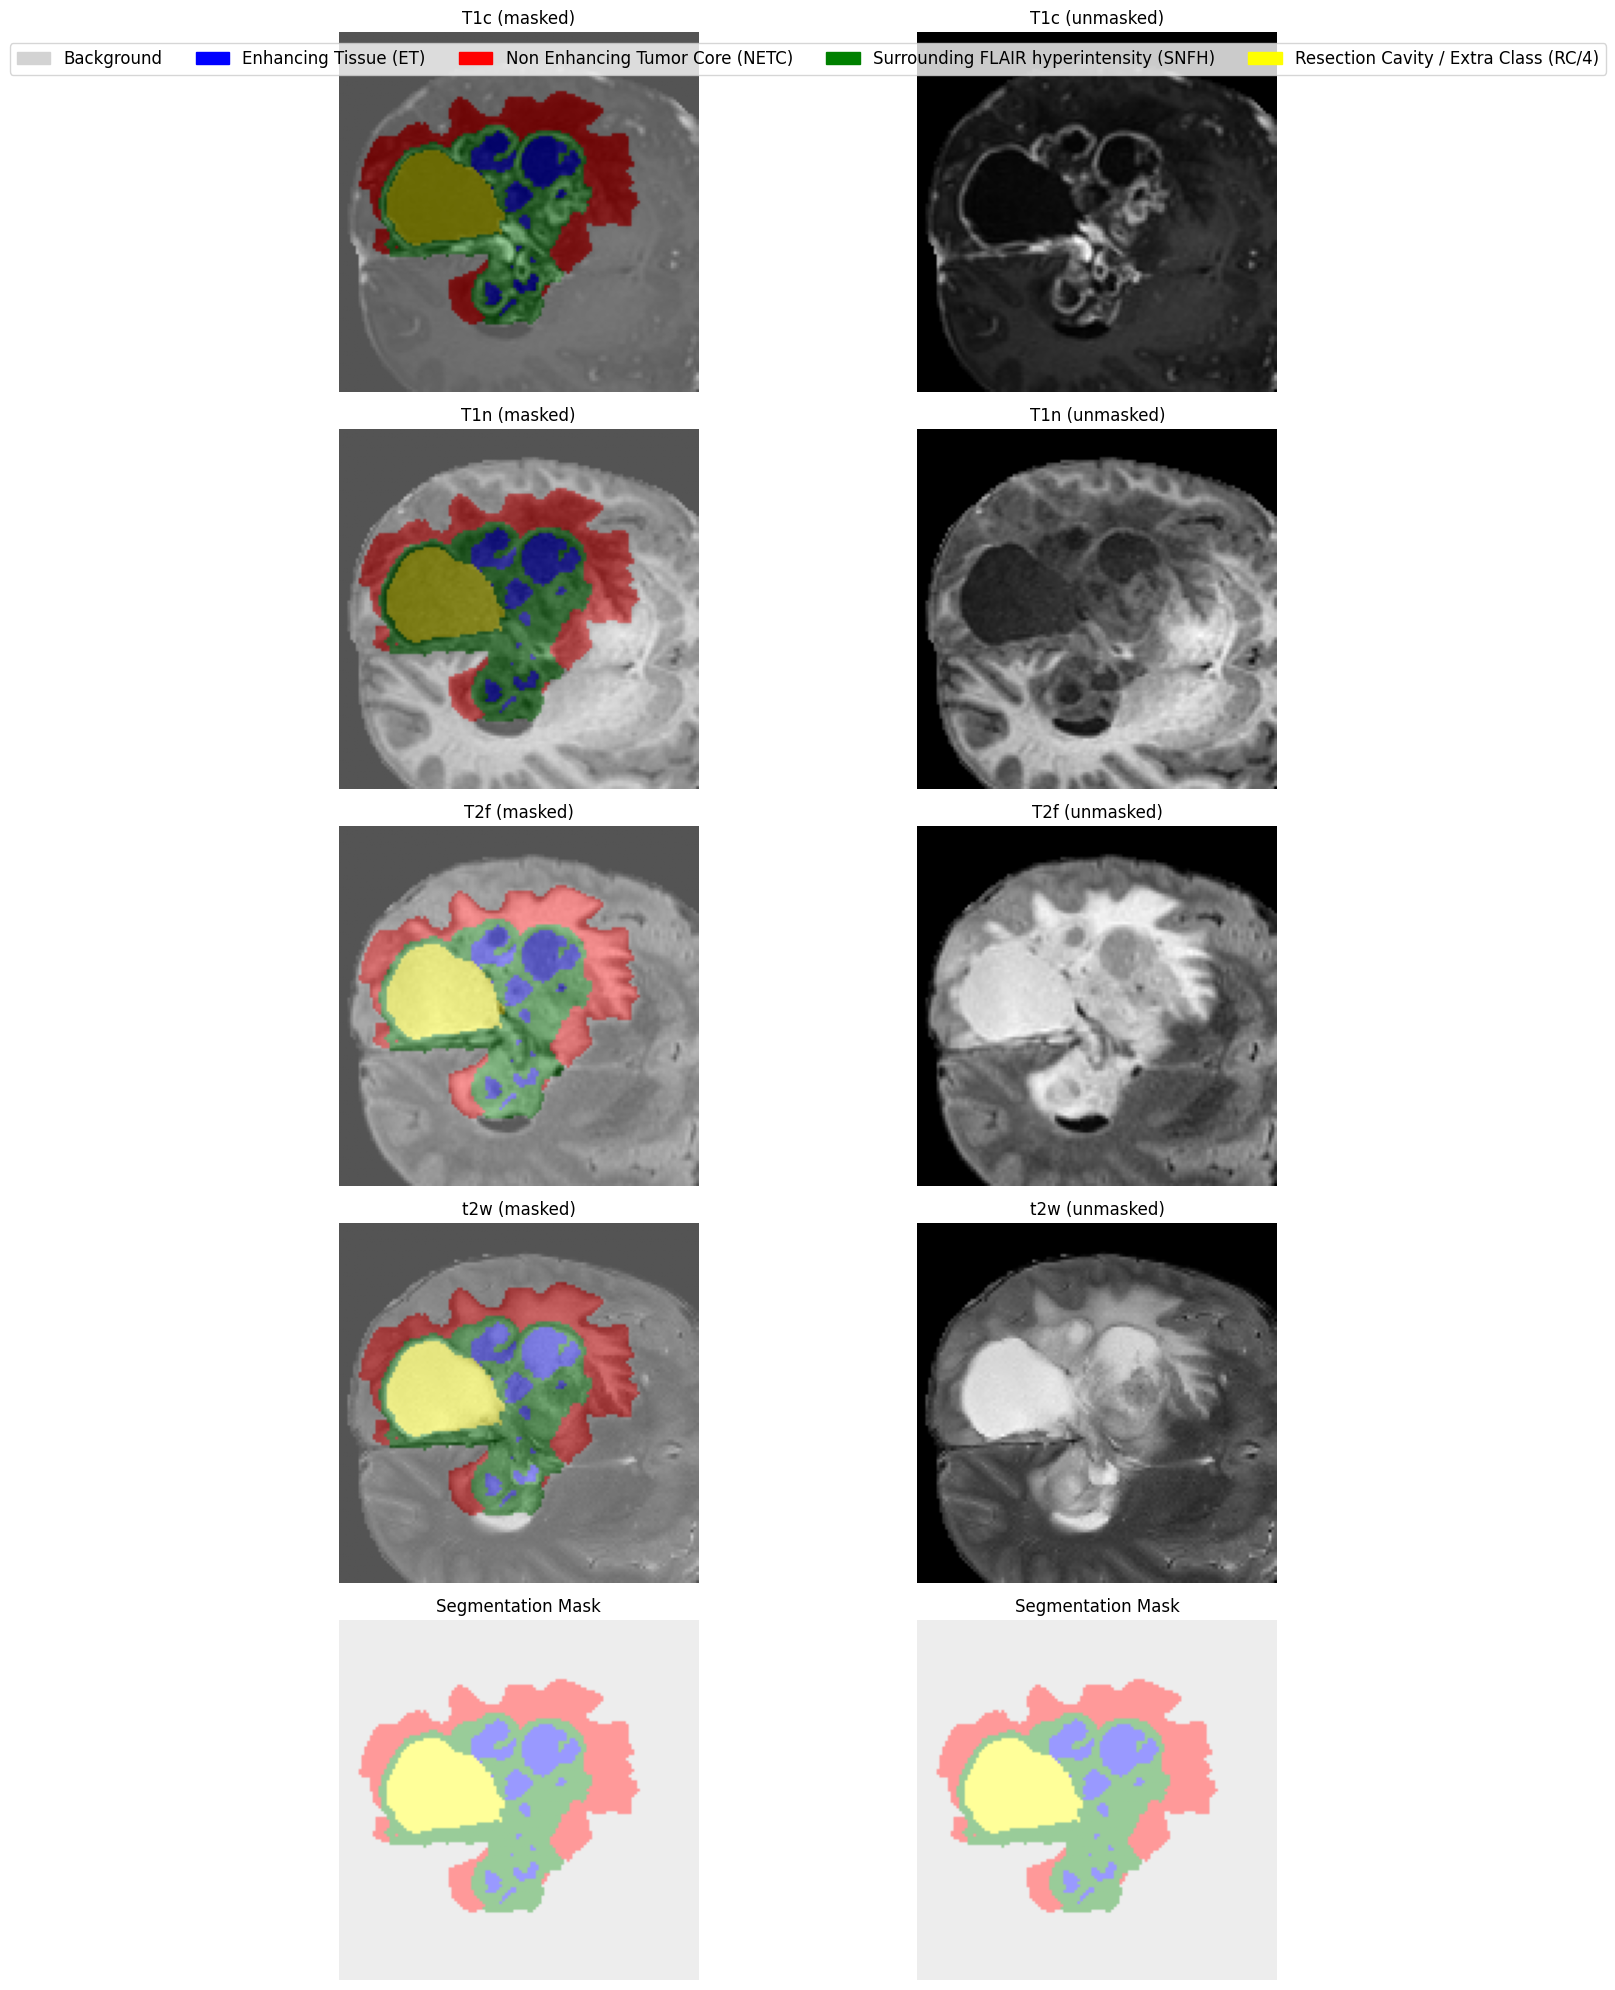

In [4]:
import random
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from matplotlib.patches import Patch



# Manually load one specific patient
X, Y, mask_raw = load_single_patient_full(root_dir, "BraTS-GLI-02318-100")

test_img_full  = X[0]        # (H, W, D, 4)
test_mask_full = Y[0]        # (H, W, D, 5)  one-hot
mask_raw                     # (H, W, D)     raw integer labels — for visualization


test_img = np.expand_dims(X[0], axis=0)  # shape: 1,H,W,D,4
test_mask = Y[0] 


# Modalities
modalities = ['T1c', 'T1n', 'T2f', 't2w']

# Select a patient from the batch
test_img = X[0]
test_mask = Y[0]

# Convert one-hot → labels
mask_slice = np.argmax(test_mask[:, :, 64, :], axis=-1)  # shape: H x W

# Define colors for 5 classes
colors_mask = ['lightgray', 'blue', 'red', 'green', 'yellow']  # 0=background
cmap_mask = matplotlib.colors.ListedColormap(colors_mask)

# Class names for 5 classes
class_names = [
    "Background",
    "Enhancing Tissue (ET)",
    "Non Enhancing Tumor Core (NETC)",
    "Surrounding FLAIR hyperintensity (SNFH)",
    "Resection Cavity / Extra Class (RC/4)"
]

# Create figure
fig, axs = plt.subplots(5, 2, figsize=(14, 20))  # 4 modalities + mask row, 2 columns

# Plot masked vs unmasked modalities
for i in range(4):
    # Masked
    axs[i, 0].imshow(test_img[:, :, 64, i], cmap='gray')
    axs[i, 0].imshow(mask_slice, cmap=cmap_mask, alpha=0.4)
    axs[i, 0].set_title(f"{modalities[i]} (masked)")
    axs[i, 0].axis('off')
    
    # Unmasked
    axs[i, 1].imshow(test_img[:, :, 64, i], cmap='gray')
    axs[i, 1].set_title(f"{modalities[i]} (unmasked)")
    axs[i, 1].axis('off')

# Mask alone (last row)
for j in range(2):
    axs[4, j].imshow(mask_slice, cmap=cmap_mask, alpha=0.4)
    axs[4, j].set_title("Segmentation Mask")
    axs[4, j].axis('off')

# Legend for classes
patches = [Patch(color=colors_mask[i], label=class_names[i]) for i in range(len(class_names))]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 0.98), fontsize=12, ncol=5)

plt.tight_layout()
plt.show()


In [5]:
from tensorflow.keras import backend as K


def dice_coef_class(y_true, y_pred, class_index, epsilon=1e-6):
    intersection = K.sum(K.abs(y_true[:,:,:,:,class_index] *
                               y_pred[:,:,:,:,class_index]))
    
    return (2. * intersection) / ( 
        K.sum(K.square(y_true[:,:,:,:,class_index])) +
        K.sum(K.square(y_pred[:,:,:,:,class_index])) + epsilon
    )





def dice_coef_whole(y_true, y_pred, epsilon=1e-6):
    class_num = y_true.shape[-1]   # automatically detect number of classes
    total_dice = 0

    for i in range(class_num):
        y_true_f = K.flatten(y_true[:,:,:,:,i])
        y_pred_f = K.flatten(y_pred[:,:,:,:,i])

        intersection = K.sum(y_true_f * y_pred_f)

        dice = (2. * intersection) / (
            K.sum(K.square(y_true_f)) +
            K.sum(K.square(y_pred_f)) +
            epsilon
        )

        total_dice += dice

    return total_dice / class_num


In [6]:
import tensorflow as tf

@tf.function
def diceTumorCore(y_true, y_pred, smooth=1.0):
    """
    Tumor Core Dice = ET + NETC
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # ET + NETC channels
    y_true_tc = y_true[..., 1] + y_true[..., 2]
    y_pred_tc = y_pred[..., 1] + y_pred[..., 2]
    
    intersection = tf.reduce_sum(y_true_tc * y_pred_tc)
    denominator  = tf.reduce_sum(y_true_tc + y_pred_tc)
    
    return (2. * intersection + smooth) / (denominator + smooth)



@tf.function
def diceWholeTumor(y_true, y_pred, smooth=1.0):
    """
    Whole Tumor Dice = ET + NETC + SNFH
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # ET + NETC + SNFH
    y_true_wt = y_true[..., 1] + y_true[..., 2] + y_true[..., 3]
    y_pred_wt = y_pred[..., 1] + y_pred[..., 2] + y_pred[..., 3]
    
    intersection = tf.reduce_sum(y_true_wt * y_pred_wt)
    denominator  = tf.reduce_sum(y_true_wt + y_pred_wt)
    
    return (2. * intersection + smooth) / (denominator + smooth)

In [7]:
import numpy as np
from scipy.ndimage import distance_transform_edt, binary_erosion

def hd95(pred, gt):
    """
    Compute 95th percentile Hausdorff Distance (HD95) for 3D binary masks.
    
    Parameters:
        pred: binary numpy array (prediction mask)
        gt:   binary numpy array (ground truth mask)
    
    Returns:
        HD95 value (float)
    """

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    # Case 1: both empty -> perfect match
    if pred.sum() == 0 and gt.sum() == 0:
        return 0.0

    # Case 2: one empty -> undefined / invalid
    if pred.sum() == 0 or gt.sum() == 0:
        return np.nan   # better than np.inf for averaging

    # Extract surfaces (boundary voxels only)
    pred_eroded = binary_erosion(pred)
    gt_eroded = binary_erosion(gt)

    surface_pred = pred ^ pred_eroded
    surface_gt = gt ^ gt_eroded

    # Safety check
    if surface_pred.sum() == 0 or surface_gt.sum() == 0:
        return np.nan

    # Distance transforms of inverse surfaces
    dt_pred = distance_transform_edt(~surface_pred)
    dt_gt = distance_transform_edt(~surface_gt)

    # Surface-to-surface distances
    distances_pred_to_gt = dt_gt[surface_pred]
    distances_gt_to_pred = dt_pred[surface_gt]

    all_distances = np.concatenate([distances_pred_to_gt, distances_gt_to_pred])

    if all_distances.size == 0:
        return np.nan

    return np.percentile(all_distances, 95)

In [8]:
import numpy as np
from scipy.ndimage import distance_transform_edt, binary_erosion
import gc


#  YOUR EXISTING HD95 FUNCTION — unchanged
def hd95(pred, gt):
    """
    Compute 95th percentile Hausdorff Distance (HD95) for 3D binary masks.
    """
    pred = pred.astype(bool)
    gt   = gt.astype(bool)

    if pred.sum() == 0 and gt.sum() == 0:
        return 0.0
    if pred.sum() == 0 or gt.sum() == 0:
        return np.nan

    pred_eroded  = binary_erosion(pred)
    gt_eroded    = binary_erosion(gt)
    surface_pred = pred ^ pred_eroded
    surface_gt   = gt   ^ gt_eroded

    if surface_pred.sum() == 0 or surface_gt.sum() == 0:
        return np.nan

    dt_pred = distance_transform_edt(~surface_pred)
    dt_gt   = distance_transform_edt(~surface_gt)

    distances_pred_to_gt = dt_gt[surface_pred]
    distances_gt_to_pred = dt_pred[surface_gt]
    all_distances        = np.concatenate([distances_pred_to_gt, distances_gt_to_pred])

    if all_distances.size == 0:
        return np.nan

    return np.percentile(all_distances, 95)


#  YOUR EXISTING evaluate_hd95 — unchanged
def evaluate_hd95(model, test_generator, steps, num_classes=5):
    """
    Memory-safe HD95 for individual tumor classes (1–4).
    Excludes background (class 0).
    """
    hd_per_class = {i: [] for i in range(1, num_classes)}

    for step in range(steps):
        X, y_true = next(test_generator)
        y_pred = model.predict(X, batch_size=1, verbose=0)

        y_pred = np.argmax(y_pred, axis=-1)
        y_true = np.argmax(y_true, axis=-1)

        batch_size_local = y_true.shape[0]
        for b in range(batch_size_local):
            for cls in range(1, num_classes):
                true_mask = (y_true[b] == cls).astype(np.uint8)
                pred_mask = (y_pred[b] == cls).astype(np.uint8)
                hd_value  = hd95(true_mask, pred_mask)
                if hd_value is not None and np.isfinite(hd_value):
                    hd_per_class[cls].append(float(hd_value))

        del X, y_true, y_pred
        gc.collect()

        if (step + 1) % 5 == 0 or (step + 1) == steps:
            print(f"Processed {step+1}/{steps} batches for HD95")

    mean_hd_per_class = {
        cls: np.mean(vals) if len(vals) > 0 else np.nan
        for cls, vals in hd_per_class.items()
    }
    valid_values = [v for v in mean_hd_per_class.values() if np.isfinite(v)]
    mean_hd_all  = np.mean(valid_values) if len(valid_values) > 0 else np.nan

    return mean_hd_per_class, mean_hd_all

#  NEW — HD95 for Tumor Core and Whole Tumor regions

# Tumor Core  : ET (1) + NETC (2)
# Whole Tumor : ET (1) + NETC (2) + SNFH (3)
REGION_CLASSES = {
    "Tumor Core"  : [1, 2],
    "Whole Tumor" : [1, 2, 3],
}


def evaluate_hd95_regions(model, test_generator, steps):
    """
    Memory-safe HD95 for composite regions:
      - Tumor Core  : ET + NETC        (classes 1, 2)
      - Whole Tumor : ET + NETC + SNFH (classes 1, 2, 3)

    Works by merging the relevant per-class binary masks into one
    region mask, then calling the same hd95() as above.

    Parameters
    ----------
    model          : trained Keras model
    test_generator : batch generator yielding (X, Y_onehot)
    steps          : number of batches

    Returns
    -------
    mean_hd_regions : dict  {"Tumor Core": float, "Whole Tumor": float}
    """
    hd_per_region = {region: [] for region in REGION_CLASSES}

    for step in range(steps):
        X, y_true = next(test_generator)
        y_pred    = model.predict(X, batch_size=1, verbose=0)

        # softmax → hard class-index labels
        y_pred_labels = np.argmax(y_pred, axis=-1)   # (B, H, W, D)
        y_true_labels = np.argmax(y_true, axis=-1)   # (B, H, W, D)

        batch_size_local = y_true_labels.shape[0]

        for b in range(batch_size_local):
            pred_vol = y_pred_labels[b]   # (H, W, D)
            true_vol = y_true_labels[b]   # (H, W, D)

            for region, class_indices in REGION_CLASSES.items():
                # Merge: foreground = any voxel belonging to the region classes
                pred_mask = np.isin(pred_vol, class_indices).astype(np.uint8)
                true_mask = np.isin(true_vol, class_indices).astype(np.uint8)

                hd_value = hd95(pred_mask, true_mask)
                if hd_value is not None and np.isfinite(hd_value):
                    hd_per_region[region].append(float(hd_value))

        del X, y_true, y_pred, y_pred_labels, y_true_labels
        gc.collect()

        if (step + 1) % 5 == 0 or (step + 1) == steps:
            print(f"Processed {step+1}/{steps} batches for region HD95")

    mean_hd_regions = {
        region: np.mean(vals) if len(vals) > 0 else np.nan
        for region, vals in hd_per_region.items()
    }

    return mean_hd_regions

In [9]:
import pandas as pd
history = pd.read_csv('/kaggle/input/datasets/muhammadwahajsajid/full-dataset-training-ouput/training_brats2024_tumor_centered_patching.log', sep=',', engine='python')
print(history.columns)


Index(['epoch', 'dice_ET', 'dice_NETC', 'dice_RC', 'dice_SNFH', 'dice_bg',
       'dice_coef', 'dice_tumor_core', 'dice_whole_tumor', 'learning_rate',
       'loss', 'val_dice_ET', 'val_dice_NETC', 'val_dice_RC', 'val_dice_SNFH',
       'val_dice_bg', 'val_dice_coef', 'val_dice_tumor_core',
       'val_dice_whole_tumor', 'val_loss'],
      dtype='object')


I0000 00:00:1776834379.657883      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


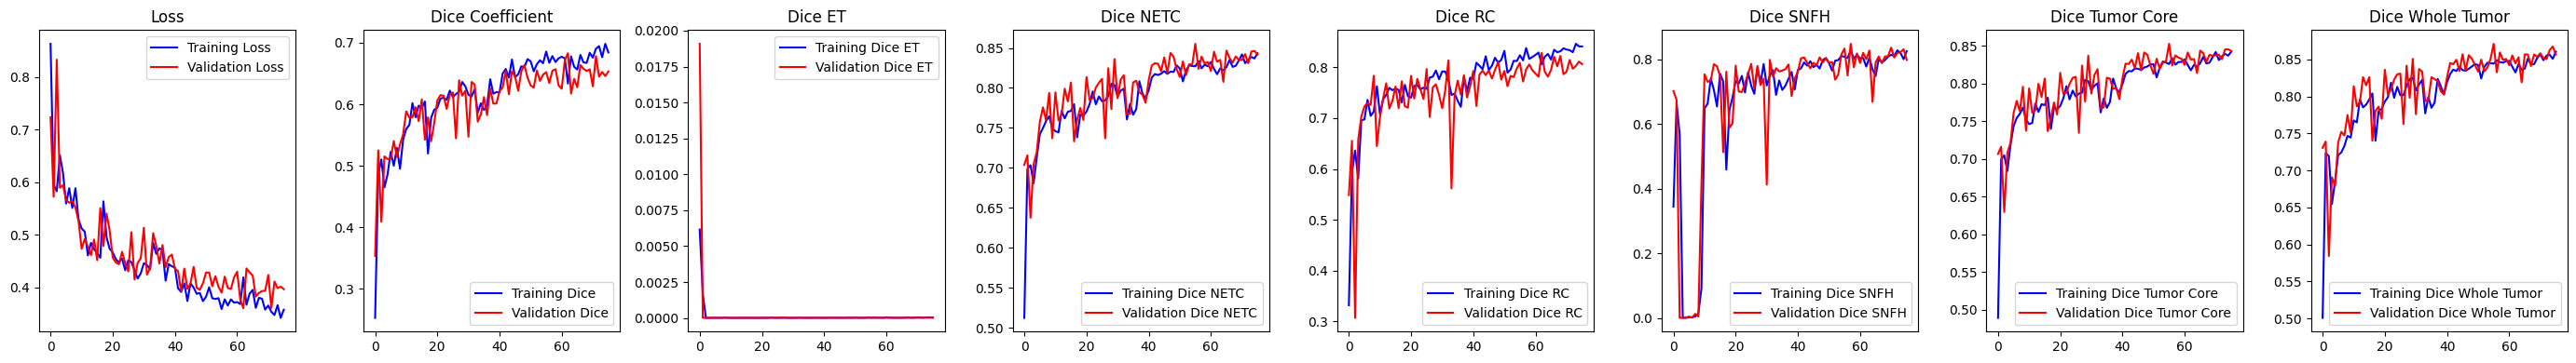

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

def instance_normalization(x, epsilon=1e-5):
    mean, var = tf.nn.moments(x, axes=[1,2,3], keepdims=True)
    return (x - mean) / tf.sqrt(var + epsilon)

model_directory = '/kaggle/input/datasets/muhammadwahajsajid/full-dataset-training-ouput/model_brats_3d_unet_tumor_centered_patching.keras'
model = tf.keras.models.load_model(
    model_directory,
    custom_objects={
        "dice_coef_whole": dice_coef_whole,
        "instance_normalization": instance_normalization
    },
    compile=False,
    safe_mode=False
)

# Load training log
history = pd.read_csv('/kaggle/input/datasets/muhammadwahajsajid/full-dataset-training-ouput/training_brats2024_tumor_centered_patching.log', sep=',', engine='python')
hist = history

# Extract columns
epoch = range(len(hist))
loss          = hist['loss']
val_loss      = hist['val_loss']
train_dice    = hist['dice_coef']
val_dice      = hist['val_dice_coef']
dice_ET       = hist['dice_ET']
val_dice_ET   = hist['val_dice_ET']       # Fix: was ['val_dice_ET']
dice_NETC     = hist['dice_NETC']
val_dice_NETC = hist['val_dice_NETC']     # Fix: was ['val_dice_NETC']
dice_RC       = hist['dice_RC']
val_dice_RC   = hist['val_dice_RC']       # Fix: was ['val_dice_RC']
dice_SNFH     = hist['dice_SNFH']         # Fix: was ['dice_SNFH']
val_dice_SNFH = hist['val_dice_SNFH']
dice_tumor_core = hist ['dice_tumor_core']
val_dice_tumor_core = hist ['val_dice_tumor_core']
dice_whole_tumor = hist['dice_whole_tumor']
val_dice_whole_tumor =  hist['val_dice_whole_tumor']
learning_rate = hist['learning_rate']


# Plot — use 8 subplots, one per metric
f, ax = plt.subplots(1, 8, figsize=(28, 4))

ax[0].plot(epoch, loss, 'b', label='Training Loss')
ax[0].plot(epoch, val_loss, 'r', label='Validation Loss')
ax[0].legend()
ax[0].set_title('Loss')

ax[1].plot(epoch, train_dice, 'b', label='Training Dice')
ax[1].plot(epoch, val_dice, 'r', label='Validation Dice')
ax[1].legend()
ax[1].set_title('Dice Coefficient')

ax[2].plot(epoch, dice_ET, 'b', label='Training Dice ET')      # Fix: ax[2] not shared
ax[2].plot(epoch, val_dice_ET, 'r', label='Validation Dice ET')
ax[2].legend()
ax[2].set_title('Dice ET')

ax[3].plot(epoch, dice_NETC, 'b', label='Training Dice NETC')  # Fix: ax[3]
ax[3].plot(epoch, val_dice_NETC, 'r', label='Validation Dice NETC')
ax[3].legend()
ax[3].set_title('Dice NETC')

ax[4].plot(epoch, dice_RC, 'b', label='Training Dice RC')      # Fix: ax[4]
ax[4].plot(epoch, val_dice_RC, 'r', label='Validation Dice RC')
ax[4].legend()
ax[4].set_title('Dice RC')

ax[5].plot(epoch, dice_SNFH, 'b', label='Training Dice SNFH')  # Fix: ax[5], typo fixed
ax[5].plot(epoch, val_dice_SNFH, 'r', label='Validation Dice SNFH')
ax[5].legend()
ax[5].set_title('Dice SNFH')


ax[6].plot(epoch, dice_tumor_core, 'b', label='Training Dice Tumor Core')  # Fix: ax[5], typo fixed
ax[6].plot(epoch, val_dice_tumor_core, 'r', label='Validation Dice Tumor Core')
ax[6].legend()
ax[6].set_title('Dice Tumor Core')


ax[7].plot(epoch, dice_whole_tumor, 'b', label='Training Dice Whole Tumor')  # Fix: ax[5], typo fixed
ax[7].plot(epoch, val_dice_whole_tumor, 'r', label='Validation Dice Whole Tumor')
ax[7].legend()
ax[7].set_title('Dice Whole Tumor')



plt.tight_layout()
plt.savefig('training_result_2026_cca.png')
plt.show()

In [11]:
import numpy as np
import tensorflow as tf
import gc

# Updated to 5 classes
n_classes = 5

class_names = [
    "Background",
    "ET",
    "NETC",
    "SNFH",
    "RC"
]

# Batch settings
batch_size = 1
val_gen = imageLoader_full(root_dir, all_patients, batch_size=batch_size)

steps = len(all_patients) // batch_size + int(len(all_patients) % batch_size > 0)


# Running sums for Dice
dice_sums = np.zeros(n_classes, dtype=np.float64)
whole_dice_sum = 0.0
valid_batches = 0

print(f"Total evaluation steps: {steps}")

# Evaluate batch by batch (NO accumulation)
for step in range(steps):
    X_batch, Y_batch = next(val_gen)

    # Predict current batch only
    Y_pred_batch = model.predict(X_batch, verbose=0)

    # Convert predictions to hard one-hot labels
    Y_pred_argmax = tf.argmax(Y_pred_batch, axis=4)
    Y_pred_onehot = tf.one_hot(Y_pred_argmax, depth=n_classes)
    Y_pred_onehot = tf.cast(Y_pred_onehot, tf.float32)

    Y_batch_tensor = tf.convert_to_tensor(Y_batch, dtype=tf.float32)

    # Dice per class
    for c in range(n_classes):
        dice_c = dice_coef_class(Y_batch_tensor, Y_pred_onehot, c)
        dice_sums[c] += float(dice_c.numpy())

    # Whole Dice (includes background)
    whole_dice = dice_coef_whole(Y_batch_tensor, Y_pred_onehot)
    whole_dice_sum += float(whole_dice.numpy())

    valid_batches += 1

    # Free memory manually
    del X_batch, Y_batch, Y_pred_batch, Y_pred_argmax, Y_pred_onehot, Y_batch_tensor
    gc.collect()

    if (step + 1) % 5 == 0 or (step + 1) == steps:
        print(f"Processed {step+1}/{steps} batches")

# Final averages
dice_per_class = dice_sums / valid_batches
mean_dice = whole_dice_sum / valid_batches

# Print Results
print("\n===== MEMORY-SAFE FULL DATASET EVALUATION =====")

for c in range(n_classes):
    print(f"Dice - {class_names[c]}: {dice_per_class[c]:.4f}")

print(f"\nMean Dice (Whole, incl. background): {mean_dice:.4f}")

Total evaluation steps: 225


I0000 00:00:1776834386.336221     123 service.cc:152] XLA service 0x7b3170110820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776834386.336267     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776834386.651315     123 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-22 05:06:27.564769: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 05:06:27.771923: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 05:06:28.121997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

Processed 5/225 batches
Processed 10/225 batches
Processed 15/225 batches
Processed 20/225 batches
Processed 25/225 batches
Processed 30/225 batches
Processed 35/225 batches
Processed 40/225 batches
Processed 45/225 batches
Processed 50/225 batches
Processed 55/225 batches
Processed 60/225 batches
Processed 65/225 batches
Processed 70/225 batches
Processed 75/225 batches
Processed 80/225 batches
Processed 85/225 batches
Processed 90/225 batches
Processed 95/225 batches
Processed 100/225 batches
Processed 105/225 batches
Processed 110/225 batches
Processed 115/225 batches
Processed 120/225 batches
Processed 125/225 batches
Processed 130/225 batches
Processed 135/225 batches
Processed 140/225 batches
Processed 145/225 batches
Processed 150/225 batches
Processed 155/225 batches
Processed 160/225 batches
Processed 165/225 batches
Processed 170/225 batches
Processed 175/225 batches
Processed 180/225 batches
Processed 185/225 batches
Processed 190/225 batches
Processed 195/225 batches
Proces

In [12]:
import numpy as np
import tensorflow as tf
import gc


# Settings
batch_size = 1
num_val = len(all_patients)
steps = int(np.ceil(num_val / batch_size))

# Re-create generator
val_gen = imageLoader_full(root_dir, all_patients, batch_size=batch_size)


# Accumulators for Dice
dice_tc_list = []
dice_wt_list = []

# Iterate over batches
for step in range(steps):
    X_batch, Y_batch = next(val_gen)  # batch from generator

    # Predict batch
    Y_pred_batch = model.predict(X_batch, batch_size=batch_size, verbose=0)

    # Convert predictions to one-hot if needed
    Y_pred_onehot = tf.one_hot(tf.argmax(Y_pred_batch, axis=-1), depth=n_classes)
    Y_pred_onehot = tf.cast(Y_pred_onehot, tf.float32)

    Y_true_onehot = tf.cast(Y_batch, tf.float32)

    # Compute Dice metrics
    dice_tc = diceTumorCore(Y_true_onehot, Y_pred_onehot).numpy()
    dice_wt = diceWholeTumor(Y_true_onehot, Y_pred_onehot).numpy()

    dice_tc_list.append(dice_tc)
    dice_wt_list.append(dice_wt)

    # Free memory
    del X_batch, Y_batch, Y_pred_batch, Y_pred_onehot, Y_true_onehot
    gc.collect()

    if (step + 1) % 5 == 0 or (step + 1) == steps:
        print(f"Processed {step + 1}/{steps} batches")

# Compute mean Dice across all batches
mean_dice_tc = np.mean(dice_tc_list)
mean_dice_wt = np.mean(dice_wt_list)

# Print results
print("\n===== Tumor Dice Evaluation =====")
print(f"Tumor Core Dice (ET + NETC): {mean_dice_tc:.4f}")
print(f"Whole Tumor Dice (ET + NETC + SNFH): {mean_dice_wt:.4f}")

Processed 5/225 batches
Processed 10/225 batches
Processed 15/225 batches
Processed 20/225 batches
Processed 25/225 batches
Processed 30/225 batches
Processed 35/225 batches
Processed 40/225 batches
Processed 45/225 batches
Processed 50/225 batches
Processed 55/225 batches
Processed 60/225 batches
Processed 65/225 batches
Processed 70/225 batches
Processed 75/225 batches
Processed 80/225 batches
Processed 85/225 batches
Processed 90/225 batches
Processed 95/225 batches
Processed 100/225 batches
Processed 105/225 batches
Processed 110/225 batches
Processed 115/225 batches
Processed 120/225 batches
Processed 125/225 batches
Processed 130/225 batches
Processed 135/225 batches
Processed 140/225 batches
Processed 145/225 batches
Processed 150/225 batches
Processed 155/225 batches
Processed 160/225 batches
Processed 165/225 batches
Processed 170/225 batches
Processed 175/225 batches
Processed 180/225 batches
Processed 185/225 batches
Processed 190/225 batches
Processed 195/225 batches
Proces

In [13]:
# Step 1: Individual classes
val_gen = imageLoader_full(root_dir, all_patients, batch_size=1)
mean_hd_per_class, mean_hd_all = evaluate_hd95(
    model,
    val_gen,
    steps=steps,
    num_classes=5
)

# Step 2: Composite regions — re-create generator first!
val_gen = imageLoader_full(root_dir, all_patients, batch_size=1)
mean_hd_regions = evaluate_hd95_regions(
    model,
    val_gen,
    steps=steps
)

# Print all results
class_names = {1: "ET", 2: "NETC", 3: "SNFH", 4: "RC"}

print("\n===== HD95 Results (Validation/Test Set) =====")

print("\n--- Individual Classes ---")
for cls in range(1, 5):
    value = mean_hd_per_class.get(cls, np.nan)
    if np.isfinite(value):
        print(f"  HD95 - {class_names[cls]:<6}: {value:.4f} mm")
    else:
        print(f"  HD95 - {class_names[cls]:<6}: NaN (no valid samples)")

if np.isfinite(mean_hd_all):
    print(f"\n  Mean HD95 (Tumor Classes 1-4): {mean_hd_all:.4f} mm")
else:
    print("\n  Mean HD95 (Tumor Classes 1-4): NaN")

print("\n--- Composite Regions ---")
region_labels = {
    "Tumor Core"  : "Tumor Core   (ET + NETC)",
    "Whole Tumor" : "Whole Tumor  (ET + NETC + SNFH)",
}
for region, label in region_labels.items():
    value = mean_hd_regions.get(region, np.nan)
    if np.isfinite(value):
        print(f"  HD95 - {label}: {value:.4f} mm")
    else:
        print(f"  HD95 - {label}: NaN (no valid samples)")

Processed 5/225 batches for HD95
Processed 10/225 batches for HD95
Processed 15/225 batches for HD95
Processed 20/225 batches for HD95
Processed 25/225 batches for HD95
Processed 30/225 batches for HD95
Processed 35/225 batches for HD95
Processed 40/225 batches for HD95
Processed 45/225 batches for HD95
Processed 50/225 batches for HD95
Processed 55/225 batches for HD95
Processed 60/225 batches for HD95
Processed 65/225 batches for HD95
Processed 70/225 batches for HD95
Processed 75/225 batches for HD95
Processed 80/225 batches for HD95
Processed 85/225 batches for HD95
Processed 90/225 batches for HD95
Processed 95/225 batches for HD95
Processed 100/225 batches for HD95
Processed 105/225 batches for HD95
Processed 110/225 batches for HD95
Processed 115/225 batches for HD95
Processed 120/225 batches for HD95
Processed 125/225 batches for HD95
Processed 130/225 batches for HD95
Processed 135/225 batches for HD95
Processed 140/225 batches for HD95
Processed 145/225 batches for HD95
Proce

In [14]:
print("Background Dice (raw):", float(dice_per_class[0]))

Background Dice (raw): 0.9959615079561869


In [15]:
import numpy as np
import gc

# Settings
batch_size = 1
num_val = len(all_patients)
steps = int(np.ceil(num_val / batch_size))


# Re-create generator
val_gen = imageLoader_full(root_dir, all_patients, batch_size=batch_size)


# Sets to store unique labels
unique_pred_labels = set()
unique_true_labels = set()


# Iterate batch by batch
for step in range(steps):
    X_batch, Y_batch = next(val_gen)

    # Convert GT to class indices
    Y_true_labels = np.argmax(Y_batch, axis=-1)

    # Predict batch
    Y_pred_batch = model.predict(X_batch, batch_size=batch_size, verbose=0)
    Y_pred_labels = np.argmax(Y_pred_batch, axis=-1)

    # Update unique labels
    unique_true_labels.update(np.unique(Y_true_labels))
    unique_pred_labels.update(np.unique(Y_pred_labels))

    # Free memory
    del X_batch, Y_batch, Y_true_labels, Y_pred_batch, Y_pred_labels
    gc.collect()
    
    if (step + 1) % 5 == 0 or (step + 1) == steps:
        print(f"Processed {step + 1}/{steps} batches")

# Convert sets to sorted arrays and print
unique_true_labels = np.array(sorted(unique_true_labels))
unique_pred_labels = np.array(sorted(unique_pred_labels))

print("Unique ground-truth labels:", unique_true_labels)
print("Unique predicted labels:", unique_pred_labels)

Processed 5/225 batches
Processed 10/225 batches
Processed 15/225 batches
Processed 20/225 batches
Processed 25/225 batches
Processed 30/225 batches
Processed 35/225 batches
Processed 40/225 batches
Processed 45/225 batches
Processed 50/225 batches
Processed 55/225 batches
Processed 60/225 batches
Processed 65/225 batches
Processed 70/225 batches
Processed 75/225 batches
Processed 80/225 batches
Processed 85/225 batches
Processed 100/225 batches
Processed 105/225 batches
Processed 110/225 batches
Processed 115/225 batches
Processed 120/225 batches
Processed 125/225 batches
Processed 130/225 batches
Processed 135/225 batches
Processed 140/225 batches
Processed 145/225 batches
Processed 150/225 batches
Processed 155/225 batches
Processed 160/225 batches
Processed 165/225 batches
Processed 170/225 batches
Processed 175/225 batches
Processed 180/225 batches
Processed 185/225 batches
Processed 190/225 batches
Processed 195/225 batches
Processed 200/225 batches
Processed 205/225 batches
Proc

In [16]:
# print("Test mask shape: ", test_mask.shape)
# print("Test image shape: ", test_img.shape)
# print("Test Prediction shape: ", test_prediction[0].shape)

✅ Loaded patient  : BraTS-GLI-02318-100
   X shape         : (1, 128, 128, 128, 4)
   Y shape         : (1, 128, 128, 128, 5)
   Classes in mask : [0 1 2 3 4]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


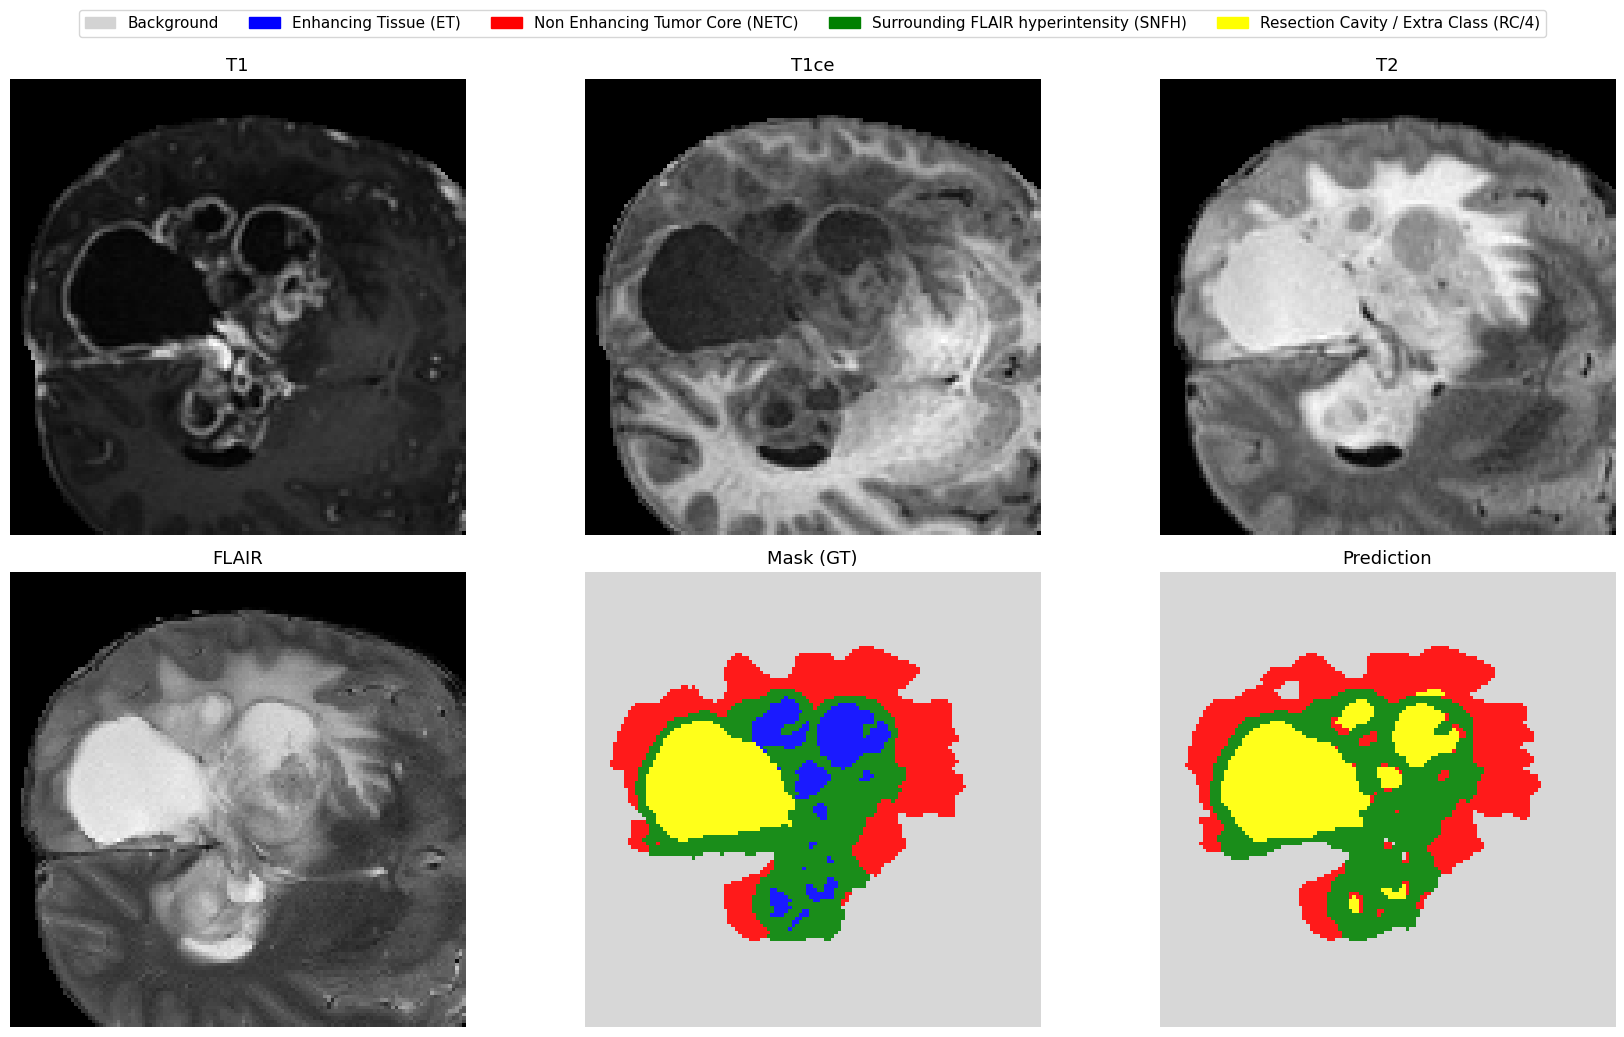

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import numpy as np



# Manually load one specific patient
X, Y, mask_raw = load_single_patient_full(root_dir, "BraTS-GLI-02318-100")

test_img_full  = X[0]        # (H, W, D, 4)
test_mask_full = Y[0]        # (H, W, D, 5)  one-hot
mask_raw                     # (H, W, D)     raw integer labels — for visualization


test_img = np.expand_dims(X[0], axis=0)  # shape: 1,H,W,D,4
test_mask = Y[0] 

# Run inference on that specific patient
test_prediction = model.predict(test_img)   



# Data
test_img_4mod  = test_img[0]           # shape: H, W, D, 4
test_mask_4mod = test_mask        # shape: H, W, D, 5  (one-hot, 5 classes)
prediction     = test_prediction[0]

# Colormap & legend config
colors_mask = ['lightgray', 'blue', 'red', 'green', 'yellow']   # 0 = background
cmap_mask   = matplotlib.colors.ListedColormap(colors_mask)

class_names = [
    "Background",
    "Enhancing Tissue (ET)",
    "Non Enhancing Tumor Core (NETC)",
    "Surrounding FLAIR hyperintensity (SNFH)",
    "Resection Cavity / Extra Class (RC/4)"
]

# Figure & subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Modality 1: T1
axes[0, 0].imshow(test_img_4mod[:, :, 64, 0], cmap='gray')
axes[0, 0].set_title('T1', fontsize=13)
axes[0, 0].axis('off')

# Modality 2: T1ce
axes[0, 1].imshow(test_img_4mod[:, :, 64, 1], cmap='gray')
axes[0, 1].set_title('T1ce', fontsize=13)
axes[0, 1].axis('off')

# Modality 3: T2
axes[0, 2].imshow(test_img_4mod[:, :, 64, 2], cmap='gray')
axes[0, 2].set_title('T2', fontsize=13)
axes[0, 2].axis('off')

# Modality 4: FLAIR
axes[1, 0].imshow(test_img_4mod[:, :, 64, 3], cmap='gray')
axes[1, 0].set_title('FLAIR', fontsize=13)
axes[1, 0].axis('off')

# Ground Truth Mask
axes[1, 1].imshow(
    np.argmax(test_mask_4mod[:, :, 64, :], axis=2),
    cmap=cmap_mask, vmin=0, vmax=4, alpha=0.9
)
axes[1, 1].set_title('Mask (GT)', fontsize=13)
axes[1, 1].axis('off')

# Prediction
axes[1, 2].imshow(
    np.argmax(prediction[:, :, 64, :], axis=2),
    cmap=cmap_mask, vmin=0, vmax=4, alpha=0.9
)
axes[1, 2].set_title('Prediction', fontsize=13)
axes[1, 2].axis('off')

# Legend (fix: colors_mask is a list → index with i directly)
patches = [
    mpatches.Patch(color=colors_mask[i], label=class_names[i])
    for i in range(len(class_names))
]
fig.legend(
    handles=patches,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    fontsize=11,
    ncol=len(class_names),
    frameon=True
)

plt.tight_layout()
plt.show()